**ФИО студента**: Дьякова Елизавета Владиславовна

**Группа**: S4102

**Список выполненных пунктов задания**: все задачи

## **Задача 2. Реализация подсчёта треугольников**

In [1]:
pip install python-graphblas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.0/353.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 11.3 MB/s eta 0:00:00


In [2]:
import graphblas as gb
gb.init("suitesparse", blocking=False)
from graphblas import Matrix, dtypes, unary, binary, monoid, semiring, Recorder
from graphblas.io import mmread
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import os

Используя python-graphblas реализовать наивный алгоритм, для матрицы смежности
$A$, вычисляющий $A^3$ и возвращающий количество треугольников неориентированного графа.

*   Функция принимает представление неориентированного графа, удобное для неё (загрузка, конвертация и проверка неориентированности реализованы отдельно).
*   Функция возвращает число --- количество треугольников в графе.

In [3]:
def naive(A):
  A_3 = A.mxm(A.mxm(A))
  diagonal = A_3.diag()
  return int((diagonal.reduce(gb.agg.sum).value or 0) / 6)

Используя python-graphblas реализовать наивный алгоритм с маской, для матрицы смежности $A$, вычисляющий $A^2$ и возвращающий количество треугольников неориентированного графа.

*   Функция принимает представление неориентированного графа, удобное для неё (загрузка, конвертация и проверка неориентированности реализованы отдельно).
*   Функция возвращает число --- количество треугольников в графе.

In [4]:
def NaiveMask(A):
  A_2 = A.mxm(A)
  mask = A.dup(dtype=dtypes.BOOL)
  masked = A_2.dup(mask = mask)
  return int((masked.reduce_scalar(gb.monoid.plus).value or 0) / 6)

Используя python-graphblas реализовать Сohen's algorithm, вычисляющий количество треугольников неориентированного графа.

*   Функция принимает представление неориентированного графа, удобное для неё (загрузка, конвертация и проверка неориентированности реализованы отдельно).
*   Функция возвращает число --- количество треугольников в графе.

In [5]:
def cohen(A):
    A_tril = gb.select.tril(A)
    A_triu = gb.select.triu(A)
    mask = A.dup(dtype=dtypes.BOOL)
    return int((A_tril.mxm(A_triu).dup(mask=mask).reduce_scalar(gb.monoid.plus).value or 0) / 2)

Используя python-graphblas реализовать Sandia algorithm, вычисляющий количество треугольников неориентированного графа.

*   Функция принимает представление неориентированного графа, удобное для неё (загрузка, конвертация и проверка неориентированности реализованы отдельно).
*   Функция возвращает число --- количество треугольников в графе.

In [6]:
def sandia(A):
  A_tril = gb.select.tril(A)
  mask = A_tril.dup(dtype=dtypes.BOOL)
  return int(A_tril.mxm(A_tril).dup(mask=mask).reduce_scalar(gb.monoid.plus).value or 0)

Создадим в качестве несложного примера три матрицы с известными результатами и посмотрим, совпадают ли они при реализации разных алгоритмов.

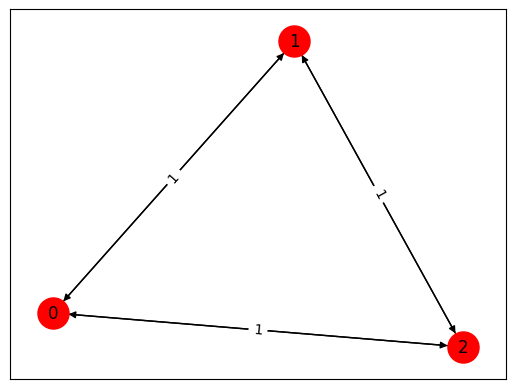

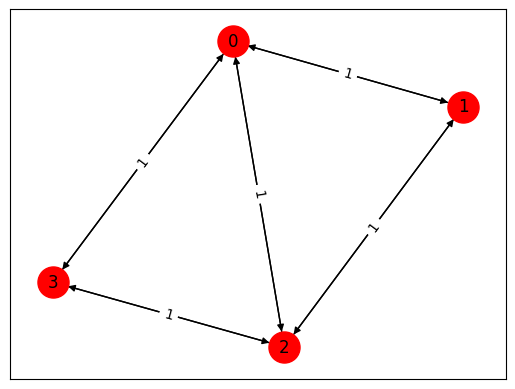

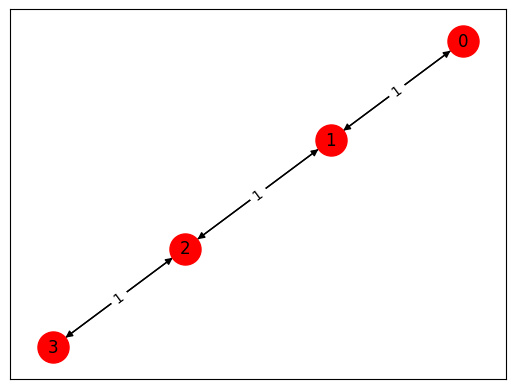

In [12]:
M_1 = gb.Matrix.from_coo(
    [0, 1, 2, 0, 2, 1],
    [1, 0, 0, 2, 1, 2],
    [1]*6,
    nrows=3, ncols=3)
gb.viz.draw(M_1)

M_2 = gb.Matrix.from_coo(
    [0, 0, 0, 1, 1, 2, 2, 2, 3, 3],
    [1, 2, 3, 0, 2, 0, 1, 3, 0, 2],
    [1]*10,
    nrows=4, ncols=4)
gb.viz.draw(M_2)

M_3 = gb.Matrix.from_coo(
    [0,1, 1,2, 2,3],
    [1,0, 2,1, 3,2],
    [1]*6,
    nrows=4, ncols=4)
gb.viz.draw(M_3)

In [13]:
def check_test(A):
  result = [naive(A), NaiveMask(A), cohen(A), sandia(A)]
  print(result)

In [14]:
check_test(M_1)

[1, 1, 1, 1]


In [15]:
check_test(M_2)

[2, 2, 2, 2]


In [16]:
check_test(M_3)

[0, 0, 0, 0]


Так, можно отметить, что результаты реализации 4-х различных алгоритмов совпадают.

В M_1 действительно один треугольник {0, 1, 2}.

В M_2 два треугольника {0, 3, 2} и {0, 1, 2}.

Граф M_3 не содержит треугольников.

(+2 балла) Используя python-graphblas реализовать функцию, вычисляющую для каждой вершины неориентированного графа количество треугольников, в которых она участвует.

*   Функция принимает представление неориентированного графа, удобное для неё (загрузка, конвертация и проверка неориентированности реализованы отдельно).
*   Функция возвращает массив, где для каждой вершины указано, в скольки треугольниках она участвует.

In [18]:
def count_triangles(A):
    A_3 = A.mxm(A.mxm(A))
    diagonal = A_3.diag()
    return (diagonal.to_dense(fill_value=0) / 2).astype(int)

Проверим результат также с помощью раннее созданных матриц

In [19]:
count_triangles(M_1)

array([1, 1, 1])

In [20]:
count_triangles(M_2)

array([2, 1, 2, 1])

In [21]:
count_triangles(M_3)

array([0, 0, 0, 0])

Результаты получились верными.

В М_1: все вершины участвуют в одном треугольнике.

В М_2: вершины 0 и 2 участвуют в двух треугольниках, а вершины 1 и 3 в одном треугольнике каждая.

M_3 не содержит треугольников, поэтому ни одна вершина не участвует в них.

(+1 балл) Скачать 10 графов в формате Matrix Market с сайта SuiteSparse Matrix Collection и оценить время работы всех полученных реализаций. Сделать выводы.

*   В качестве фильтров для поиска графов на сайте использовать следующие значения: Rutherford-Boeing Type = Binary, Special Structure = Symmetric, Nonzeros.Min = 10000.

In [23]:
graphs = {
    "bcspwr10":  mmread('bcspwr10.mtx'),
    "bcsstk29":  mmread('bcsstk29.mtx'),
    "bcsstk30":  mmread('bcsstk30.mtx'),
    "blckhole":  mmread('blckhole.mtx'),
    "can_1072":  mmread('can_1072.mtx'),
    "can_838":   mmread('can_838.mtx'),
    "dwt_2680":  mmread('dwt_2680.mtx'),
    "lshp1882":  mmread('lshp1882.mtx'),
    "eris1176":  mmread('eris1176.mtx'),
    "lshp2233":  mmread('lshp2233.mtx'),}

In [24]:
for name, M in graphs.items():
    print(f"{name} вершин={M.nrows}, рёбер={M.nvals // 2}")

bcspwr10 вершин=5300, рёбер=10921
bcsstk29 вершин=13992, рёбер=309744
bcsstk30 вершин=28924, рёбер=1021746
blckhole вершин=2132, рёбер=7436
can_1072 вершин=1072, рёбер=6222
can_838 вершин=838, рёбер=5005
dwt_2680 вершин=2680, рёбер=12513
lshp1882 вершин=1882, рёбер=6452
eris1176 вершин=1176, рёбер=9276
lshp2233 вершин=2233, рёбер=7668


In [25]:
algorithms = [("naive", naive), ("naivemask", NaiveMask), ("cohen", cohen), ("sandia", sandia)]
res    = {name: [] for name, _ in algorithms}
graph_names = list(graphs.keys())

for gname, M in graphs.items():
    for name, func in algorithms:
        start = time.time()
        func(M)
        elapsed = (time.time() - start) * 1000
        res[name].append(elapsed)
        print(f"{gname}, {name}: {elapsed:.2f} мс")

bcspwr10, naive: 24.96 мс
bcspwr10, naivemask: 9.06 мс
bcspwr10, cohen: 2.56 мс
bcspwr10, sandia: 2.41 мс
bcsstk29, naive: 1494.71 мс
bcsstk29, naivemask: 378.95 мс
bcsstk29, cohen: 177.39 мс
bcsstk29, sandia: 133.42 мс
bcsstk30, naive: 5446.53 мс
bcsstk30, naivemask: 1296.08 мс
bcsstk30, cohen: 562.11 мс
bcsstk30, sandia: 446.11 мс
blckhole, naive: 8.79 мс
blckhole, naivemask: 1.32 мс
blckhole, cohen: 1.11 мс
blckhole, sandia: 1.22 мс
can_1072, naive: 65.90 мс
can_1072, naivemask: 12.91 мс
can_1072, cohen: 2.51 мс
can_1072, sandia: 1.46 мс
can_838, naive: 49.09 мс
can_838, naivemask: 9.49 мс
can_838, cohen: 1.73 мс
can_838, sandia: 9.31 мс
dwt_2680, naive: 95.47 мс
dwt_2680, naivemask: 28.41 мс
dwt_2680, cohen: 8.00 мс
dwt_2680, sandia: 2.75 мс
lshp1882, naive: 26.99 мс
lshp1882, naivemask: 3.84 мс
lshp1882, cohen: 3.88 мс
lshp1882, sandia: 3.38 мс
eris1176, naive: 62.65 мс
eris1176, naivemask: 53.66 мс
eris1176, cohen: 30.47 мс
eris1176, sandia: 13.97 мс
lshp2233, naive: 27.66 мс
lsh

Визуализируем полученные результаты

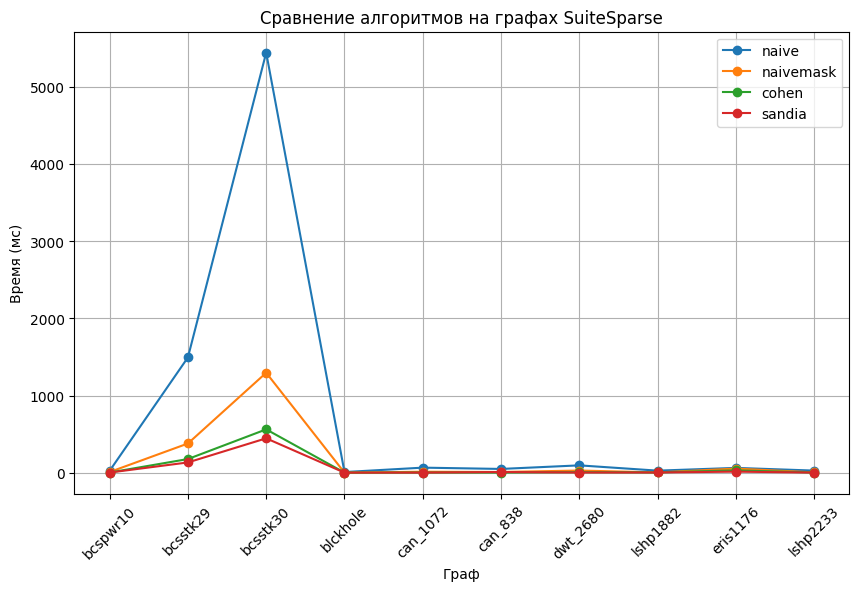

In [26]:
plt.figure(figsize=(10,6))

for name in res:
    plt.plot(graph_names, res[name], marker='o', label=name)

plt.xlabel("Граф")
plt.ylabel("Время (мс)")
plt.title("Сравнение алгоритмов на графах SuiteSparse")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

Построим тот же самый график, но без наивного алгоритма, чтобы работа других алгоритмов стала более наглядной.

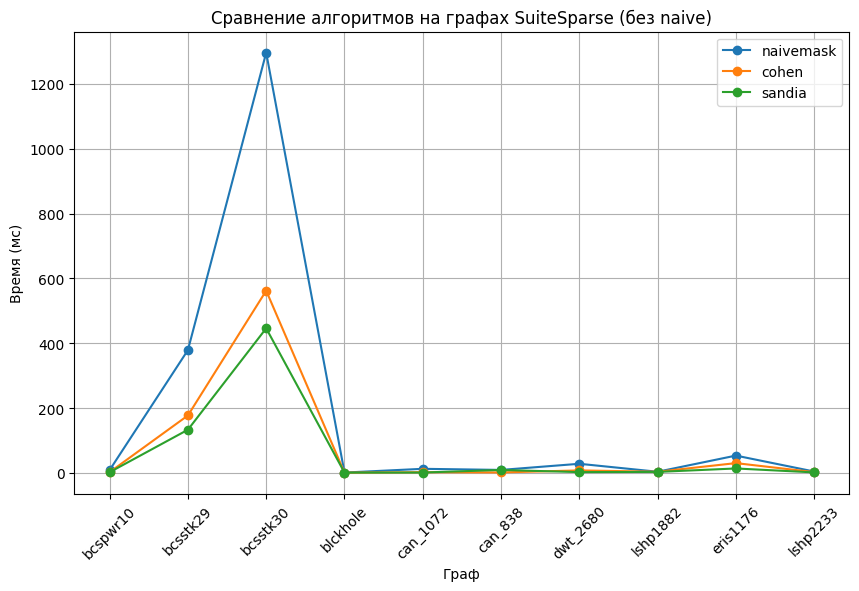

In [27]:
plt.figure(figsize=(10,6))

for name in res:
    if name != "naive":
        plt.plot(graph_names, res[name], marker='o', label=name)

plt.xlabel("Граф")
plt.ylabel("Время (мс)")
plt.title("Сравнение алгоритмов на графах SuiteSparse (без naive)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

**Выводы:** Исходя из полученных результатов, можно отметить, что время работы алгоритмов зависит от размера и структуры графа.

**Наивный алгоритм** является самым медленным, что особенно заметно на больших плотных графах. Так, например, время работы наивного алгоритма на графе bcsstk30 в 10 раз больше, чем время работы алгоритма Cohen.

**Наивный алгоритм с маской** работает заметно стабильнее и быстрее, чем наивный алгоритм примерно в 3-5 раз, но на больших графах и плотных графах время работы заметно больше в сравнении с алгоритмами Cohen и Sandia.

**Алгоритмы Cohen и Sandia** демонстрируют себя как самые эффективные алгоритмы и дают практически сопоставимые результаты по времени (в большинстве случаев Sandia оказывается немного быстрее). Данные алгоритмы работают достаточно стабильно на больших плотных графах.

(+2 балла) Реализовать генератор случайных неориентированных графов, в котором можно задавать количество вершин и степень разреженности графа. Путём генерации случайных графов различного размера и с разной степенью разреженности, оценить время работы всех полученных реализаций и исследовать границы их применимости. Сделать выводы.

In [28]:
def generate_random_graphs(n, sparsity):
  rows, cols = [], []
  for i in range(n):
      for j in range(i + 1, n):
          if random.random() < sparsity:
              rows += [i, j]
              cols += [j, i]
  if not rows:
      return gb.Matrix.from_coo([], [], [], nrows=n, ncols=n)
  return gb.Matrix.from_coo(rows, cols, [1.0] * len(rows), nrows=n, ncols=n)

In [29]:
sizes     = [10, 50, 100, 500, 1000]
sparsities = [0.2, 0.5, 0.9]
algorithms = [("naive", naive), ("naivemask", NaiveMask), ("cohen", cohen), ("sandia", sandia)]

res = {sparsity: {name: [] for name, _ in algorithms} for sparsity in sparsities}

for sparsity in sparsities:
  for n in sizes:
    G = generate_random_graphs(n, sparsity)

    for name, func in algorithms:
      start = time.time()
      func(G)
      end = time.time()
      elapsed = (end - start) * 1000
      res[sparsity][name].append(elapsed)
      print(f"n={n}, sparsity={sparsity}, {name}: {elapsed:.2f} мс")

n=10, sparsity=0.2, naive: 0.84 мс
n=10, sparsity=0.2, naivemask: 0.59 мс
n=10, sparsity=0.2, cohen: 0.52 мс
n=10, sparsity=0.2, sandia: 0.22 мс
n=50, sparsity=0.2, naive: 0.69 мс
n=50, sparsity=0.2, naivemask: 0.26 мс
n=50, sparsity=0.2, cohen: 0.35 мс
n=50, sparsity=0.2, sandia: 0.24 мс
n=100, sparsity=0.2, naive: 1.17 мс
n=100, sparsity=0.2, naivemask: 0.60 мс
n=100, sparsity=0.2, cohen: 0.53 мс
n=100, sparsity=0.2, sandia: 0.61 мс
n=500, sparsity=0.2, naive: 46.04 мс
n=500, sparsity=0.2, naivemask: 19.59 мс
n=500, sparsity=0.2, cohen: 8.58 мс
n=500, sparsity=0.2, sandia: 4.61 мс
n=1000, sparsity=0.2, naive: 281.81 мс
n=1000, sparsity=0.2, naivemask: 144.32 мс
n=1000, sparsity=0.2, cohen: 52.92 мс
n=1000, sparsity=0.2, sandia: 30.59 мс
n=10, sparsity=0.5, naive: 0.37 мс
n=10, sparsity=0.5, naivemask: 0.24 мс
n=10, sparsity=0.5, cohen: 0.34 мс
n=10, sparsity=0.5, sandia: 0.23 мс
n=50, sparsity=0.5, naive: 1.63 мс
n=50, sparsity=0.5, naivemask: 0.87 мс
n=50, sparsity=0.5, cohen: 0.70 

Визулизируем полученные результаты

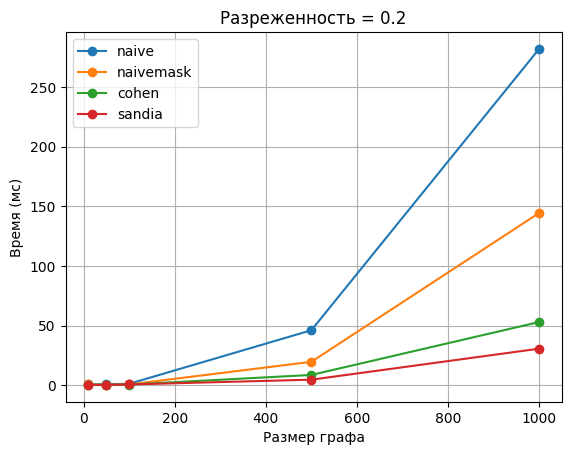

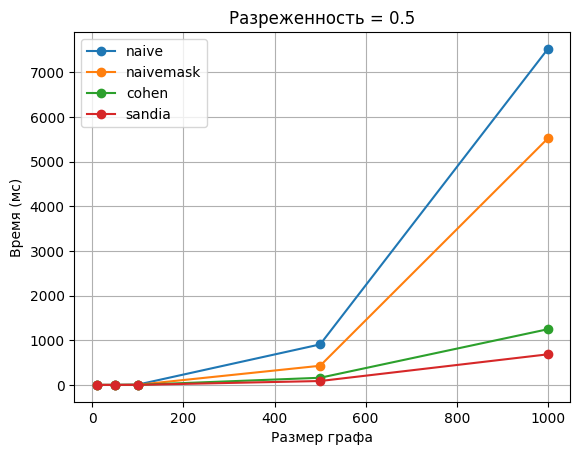

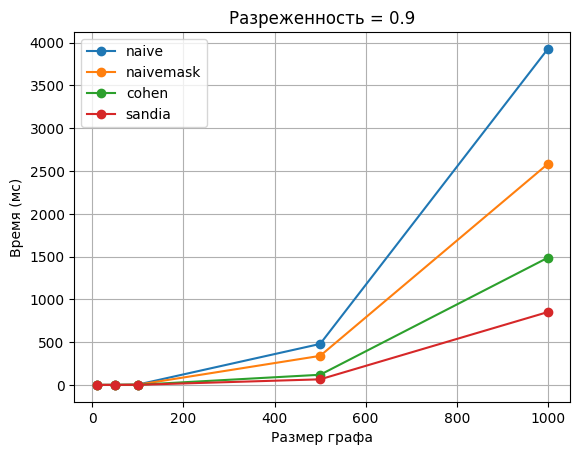

In [30]:
for sparsity in sparsities:
  plt.figure()

  for name, _ in algorithms:
    plt.plot(sizes, res[sparsity][name], marker='o', label=name)

  plt.title(f"Разреженность = {sparsity}")
  plt.xlabel("Размер графа")
  plt.ylabel("Время (мс)")
  plt.legend()
  plt.grid(True)

  plt.show()

**Выводы:** Полученные результаты в общем демонстрируют то, что при увеличении размера графа время работы всех реализаций увеличивается, а также при увеличении степени разреженнности время тоже, как правило, увеличивается, так как увеличивается количество ребер, которые нужно обработать.

**Наивный алгоритм (naive)** показывает наихудшие результаты по времени, особенно резкие изменения наблюдаются с увеличением размера графа (>100). Наивный алгоритм основан на последовательном переборе и лучше работает на небольших разреженных графах.

**Наивный алгоритм с маской** демонстрирует заметно лучшие результаты по времени, чем наивный алгоритм, что особенно заметно на графах большого размера. Это связано с тем, что наивный алгоритм с маской вычисляет только те элементы $A^2$, где в исходной матрице $A$ есть ребро, пропуская лишние операции. Тем не менее для графов большого размера (>500) алгоритм демонстрирует большой скачок по времени.

**Алгоритм Cohen** представляет более стабильное время работы для графов разных размеров и при разных уровнях разреженности, чем предыдущие алгоритмы. Алгоритм Cohen предполагает разделение матрицы смежности на нижнетреугольную и верхнетругольную, это позволяет избежать дублирование вычислений. Данный алгоритм хорошо работает на средних и больших плотных графах.

**Алгоритм Sandia** является самым быстрым и эффективным алгоритмом, благодаря оптимизированным операциям с матрицами смежности. Как можно отметить, алгоритм демонстрирует стабильные результаты при работе с большими графами и лучше масштабируется при увеличении числа вершин и рёбер.